# **MÓDULO 34 - Regressão: Conceitos Avançados**

Para essa atividade vocês trabalharão com a mesma base que usamos na aula, para previsão do aluguel.

Durante a aula montamos um modelo de regressão polinomial utilizando a variavel Valor Condominio para prever a variavel valor aluguel. Nessa atividade vocês devem escolher outra váriavel dessa base para realizar a previsão do valor do aluguel.


# 1 - Realize a importação das bibliotecas necessárias, carrega a base de dados e separe em X e Y, selecionando uma das váriaveis para X não sendo a usada durante a aula.

In [8]:
import pandas as pd

# Carregando Dados e Visualizando
df = pd.read_csv('/content/ALUGUEL_MOD12.csv', sep=";")
df.head()


,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0


In [14]:
# Estrutura e tipos de dados

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     7203 non-null   int64
 1   Valor_Condominio  7203 non-null   int64
 2   Metragem          7203 non-null   int64
 3   N_Quartos         7203 non-null   int64
 4   N_banheiros       7203 non-null   int64
 5   N_Suites          7203 non-null   int64
 6   N_Vagas           7203 non-null   int64
dtypes: int64(7)
memory usage: 394.0 KB


,0
Valor_Aluguel,0
Valor_Condominio,0
Metragem,0
N_Quartos,0
N_banheiros,0
N_Suites,0
N_Vagas,0


In [13]:
# Estatísticas descritivas

df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


In [15]:
# Variável alvo
y = df["Valor_Aluguel"]

# Variável independente
X = df[["Metragem"]]

# 2 - Faça o procecssamento dos dados utilizando o Polynomial Feature, com degree = 2.

In [16]:
from sklearn.preprocessing import PolynomialFeatures

# Criando transformação polinomial de grau 2
poly = PolynomialFeatures(degree=2)

# Aplicando a transformação em X
X_poly = poly.fit_transform(X)

# 3 - Separe os dados em treino e teste e realize o treinamento do modelo.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Separando os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# Criando o modelo de regressão linear (sobre dados polinomiais)
model = LinearRegression()

# Treinando o modelo
model.fit(X_train, y_train)

LinearRegression()

# 4 - Faça as previsões para a base de teste e avalie os resultados obtidos, não se esqueça de plotar o gráfico da regressão.

In [18]:
# Fazendo previsões com o modelo treinado
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Métricas de avaliação
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R²:", r2)
print("MAE:", mae)
print("MSE:", mse)

R²: 0.5710538044099789
MAE: 1225.4695540879295
MSE: 4645995.564625916


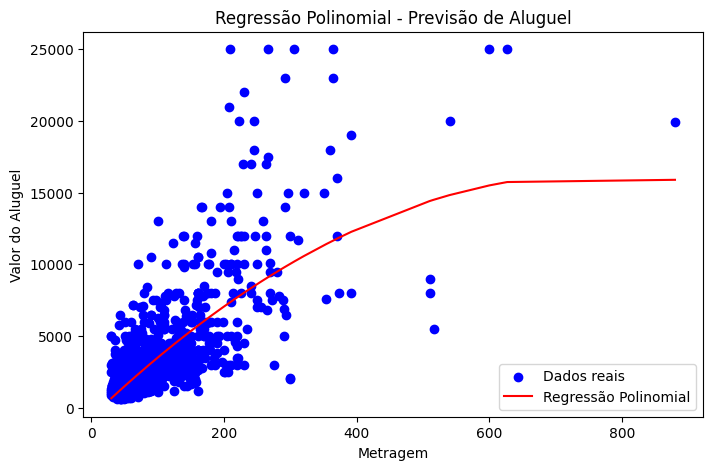

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Ordenando valores para melhor visualização da curva
X_plot = np.sort(X_test[:, 1])  # pega apenas a variável original (Metragem)
y_plot = y_pred[np.argsort(X_test[:, 1])]

plt.figure(figsize=(8,5))

# Dados reais
plt.scatter(X_test[:, 1], y_test, color="blue", label="Dados reais")

# Curva da regressão
plt.plot(X_plot, y_plot, color="red", label="Regressão Polinomial")

plt.xlabel("Metragem")
plt.ylabel("Valor do Aluguel")
plt.title("Regressão Polinomial - Previsão de Aluguel")
plt.legend()
plt.show()

# Avaliação dos Resultados

Os resultados obtidos pelo modelo de regressão polinomial de grau 2 indicam um desempenho moderado na previsão do valor do aluguel com base na metragem do imóvel. O coeficiente de determinação (R² = 0.57) mostra que aproximadamente 57% da variação do valor do aluguel é explicada pela variável metragem, o que sugere uma relação relevante, porém ainda limitada, indicando que outros fatores também influenciam significativamente o preço dos aluguéis. O erro absoluto médio (MAE ≈ 1225) demonstra que, em média, as previsões do modelo se afastam cerca de R$ 1.225 do valor real, o que pode ser considerado um erro razoável dependendo do contexto do mercado imobiliário analisado. Já o erro quadrático médio (MSE ≈ 4.65 milhões) evidencia a presença de desvios mais elevados em alguns pontos, especialmente para imóveis com valores mais altos, o que é reforçado pela dispersão observada no gráfico. Visualmente, a curva polinomial consegue capturar a tendência geral de crescimento do aluguel conforme aumenta a metragem, mas apresenta limitações ao suavizar excessivamente os extremos, não conseguindo representar perfeitamente a variabilidade dos dados reais.


---



Dessa forma, conclui-se que o modelo possui capacidade explicativa aceitável, porém ainda há espaço para melhoria, possivelmente com a inclusão de novas variáveis explicativas ou técnicas mais robustas de modelagem.

# 5 - Refaça os passos anteriores, rodando um novo modelo, porém testando agora na fase de processamento o degree = 4. Avalie se o resultado desse novo modelo está superior ao anterior.

In [22]:
# Transformação polinomial de grau 4

poly4 = PolynomialFeatures(degree=4)
X_poly4 = poly4.fit_transform(X)

# Separando os dados em treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X_poly4, y, test_size=0.2, random_state=42
)

# Modelo de regressão linear aplicado ao polinômio de grau 4
model4 = LinearRegression()
model4.fit(X_train, y_train)

# Fazendo previsões com o modelo treinado
y_pred4 = model4.predict(X_test)

# Avaliação do modelo

r2_4 = r2_score(y_test, y_pred4)
mae_4 = mean_absolute_error(y_test, y_pred4)
mse_4 = mean_squared_error(y_test, y_pred4)

print("R² (grau 4):", r2_4)
print("MAE (grau 4):", mae_4)
print("MSE (grau 4):", mse_4)

R² (grau 4): 0.5584521798250465
MAE (grau 4): 1194.128014499331
MSE (grau 4): 4782486.09078187


# Comparação entre modelos

Comparando os dois modelos, observa-se que o aumento do grau do polinômio para 4 não trouxe uma melhoria geral no desempenho. O modelo anterior apresentou um R² de 0,571, enquanto o modelo com grau 4 teve uma leve queda para 0,558, indicando uma pior explicação da variância dos dados. Em relação ao erro absoluto médio (MAE), houve uma pequena melhora, passando de 1225,47 para 1194,13, sugerindo que, em média, as previsões ficaram ligeiramente mais próximas dos valores reais. No entanto, o erro quadrático médio (MSE) aumentou de 4.645.995 para 4.782.486, o que indica maior penalização para erros mais altos e pior desempenho geral.


---


Dessa forma, apesar de uma leve melhora no MAE, o modelo com grau 4 não se mostrou superior ao anterior, sugerindo que o aumento da complexidade pode ter introduzido maior variabilidade sem ganho real na capacidade de generalização.

# 6 - Explique com suas palavras o conceito e a diferença entre Elastic Net, Ridge e Lasso.

**Ridge Regression:**
 É uma técnica de regularização que adiciona uma penalidade baseada no quadrado dos coeficientes (L2), reduzindo sua magnitude. Ela ajuda a evitar overfitting ao manter todos os atributos no modelo, apenas diminuindo sua influência. É útil quando várias variáveis contribuem para o resultado.

**Lasso Regression:**
Usa uma penalização baseada no valor absoluto dos coeficientes (L1), podendo zerar alguns deles. Isso faz com que ela realize seleção automática de variáveis, eliminando as menos importantes. É útil quando queremos simplificar o modelo e reduzir dimensionalidade.

**Elastic Net:**
Combina as penalizações L1 (Lasso) e L2 (Ridge) no mesmo modelo. Ele consegue tanto reduzir coeficientes quanto eliminar variáveis menos relevantes. É indicado quando há muitas variáveis correlacionadas entre si.